In [198]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sklearn as sk
from scipy.optimize import minimize
from matplotlib.ticker import AutoMinorLocator

In [199]:
#Save 

save = { #Se quiser salvar os resultados, basta colocar True
    'Nelder_mead': False, 
    'Rede_Neural': False,
    'OF2': False,
}

In [200]:
def reset_save():
    if save['Nelder_mead']:
        if os.path.exists('.\\results\\nm_residuals.csv'):
            os.remove('.\\results\\nm_residuals.csv')
        if os.path.exists('.\\results\\nm_stats.csv'):
            os.remove('.\\results\\nm_stats.csv')
        if os.path.exists('.\\results\\nm_amplitudes.csv'):
            os.remove('.\\results\\nm_amplitudes.csv')

    if save['Rede_Neural']:
        if os.path.exists('.\\results\\rn_residuals.csv'):
            os.remove('.\\results\\rn_residuals.csv')
        if os.path.exists('.\\results\\rn_stats.csv'):
            os.remove('.\\results\\rn_stats.csv')
        if os.path.exists('.\\results\\rn_amplitudes.csv'):
            os.remove('.\\results\\rn_amplitudes.csv')

    if save['OF2']:
        if os.path.exists('.\\results\\of2_residuals.csv'):
            os.remove('.\\results\\of2_residuals.csv')
        if os.path.exists('.\\results\\of2_stats.csv'):
            os.remove('.\\results\\of2_stats.csv')
        if os.path.exists('.\\results\\of2_amplitudes.csv'):
            os.remove('.\\results\\of2_amplitudes.csv')

In [201]:

data = [pd.read_csv(r'E:\Facul\IC\nelder-mead-for-signal-recovery\database\data_occ0_2.csv'),
        pd.read_csv(r'E:\Facul\IC\nelder-mead-for-signal-recovery\database\data_occ0_5.csv'),
        pd.read_csv(r'E:\Facul\IC\nelder-mead-for-signal-recovery\database\data_occ0_7.csv'),
        pd.read_csv(r'E:\Facul\IC\nelder-mead-for-signal-recovery\database\data_occ0_9.csv'),]

columns = data[0].columns # salva os nomes das colunas
occ_name = ['occ0.2', 'occ0.5', 'occ0.7', 'occ0.9']

In [202]:
def collect_fit(real, estimada):
    a, b = np.polyfit(real, estimada, 1)
    return a, b

In [203]:
def collect_stats(result, df):
    residual = np.array(result) - np.array(df)
    mean = np.mean(residual)
    std = np.std(residual)
    mae = np.mean(np.abs(residual))
    r2 = sk.metrics.r2_score(df, result)
    a, b = collect_fit(df, result)
    return residual, mean, std, mae, r2, (a,b)

def save_stats(name, residual, mean, std, mae, r2, ab, occ, amplitudes):
    residuals_path = f'.\\results\\{name}_residuals.csv'
    stats_path = f'.\\results\\{name}_stats.csv'
    amplitudes_path = f'.\\results\\{name}_amplitudes.csv'

    # Carrega residuais existentes ou cria DataFrame vazio
    if os.path.exists(residuals_path):
        residuals_df = pd.read_csv(residuals_path)
    else:
        residuals_df = pd.DataFrame()

    # Carrega stats existentes ou cria DataFrame vazio
    if os.path.exists(stats_path):
        stats_df = pd.read_csv(stats_path)
    else:
        stats_df = pd.DataFrame(columns=['occupancy', 'mean', 'std', 'mae', 'r2', 'ab'])

    # Carrega amplitudes existentes ou cria DataFrame vazio
    if os.path.exists(amplitudes_path):
        amplitudes_df = pd.read_csv(amplitudes_path)
    else:
        amplitudes_df = pd.DataFrame()

    # Adiciona nova coluna de resíduos e nova linha de stats
    residuals_df[f'{occ}'] = residual
    stats_df = pd.concat(
        [stats_df, pd.DataFrame({'occupancy': [occ], 'mean': [mean], 'std': [std], 'mae': [mae], 'r2': [r2], 'ab': [ab]})],
        ignore_index=True
    )
    amplitudes_df[f'{occ}'] = amplitudes

    # Salva no disco
    residuals_df.to_csv(residuals_path, index=False)
    stats_df.to_csv(stats_path, index=False)
    amplitudes_df.to_csv(amplitudes_path, index=False)

def load_results():
    nm_residuals = pd.read_csv('.\\results\\nm_residuals.csv', index_col=False)
    rn_residuals = pd.read_csv('.\\results\\rn_residuals.csv', index_col=False)
    of2_residuals = pd.read_csv('.\\results\\of2_residuals.csv', index_col=False)
    
    nm_amplitudes = pd.read_csv('.\\results\\nm_amplitudes.csv', index_col=False)
    rn_amplitudes = pd.read_csv('.\\results\\rn_amplitudes.csv', index_col=False)
    of2_amplitudes = pd.read_csv('.\\results\\of2_amplitudes.csv', index_col=False)
    
    nm_stats = pd.read_csv('.\\results\\nm_stats.csv', index_col=False)
    rn_stats = pd.read_csv('.\\results\\rn_stats.csv', index_col=False)
    of2_stats = pd.read_csv('.\\results\\of2_stats.csv', index_col=False)
    

    # nm_energias = pd.read_csv('.\\results\\nm_std_energias.csv', index_col=0)
    # rn_energias = pd.read_csv('.\\results\\rn_std_energias.csv', index_col=0)
    # of2_energias = pd.read_csv('.\\results\\of2_std_energias.csv', index_col=0)

    return nm_residuals, nm_stats, nm_amplitudes, rn_residuals, rn_stats, rn_amplitudes, of2_residuals, of2_stats, of2_amplitudes
   

In [204]:
def collect_energy(nm_amplitudes, rn_amplitudes, of2_amplitudes):
    method = ['nm', 'rn', 'of2']
    k=0
    for m in [nm_amplitudes, rn_amplitudes, of2_amplitudes]:
        std_energias = pd.DataFrame()
        i = 0
        for n in occ_name:
            en = pd.concat([m[n], data[i]['AmplitudeSample(4)']], axis=1) 
            en50 = en[en[n] < 50]
            en100 = en[en[n] >50 ]
            en100 = en100[en100[n] < 100]
            en101 = en[en[n] > 100]
            res50 = en50[n] - en50['AmplitudeSample(4)']
            res100 = en100[n] - en100['AmplitudeSample(4)']
            res101 = en101[n] - en101['AmplitudeSample(4)']
            std_energias[n] = [np.std(res50), np.std(res100), np.std(res101)]
            i+=1
        

        std_energias.to_csv(f'.\\results\\{method[k]}_std_energias.csv', index=True)

        k+=1

def load_energy(nm_amplitudes, rn_amplitudes, of2_amplitudes):
    collect_energy(nm_amplitudes, rn_amplitudes, of2_amplitudes)
    nm_energias = pd.read_csv('.\\results\\nm_std_energias.csv', index_col=0)
    rn_energias = pd.read_csv('.\\results\\rn_std_energias.csv', index_col=0)
    of2_energias = pd.read_csv('.\\results\\of2_std_energias.csv', index_col=0)

    return nm_energias, rn_energias, of2_energias

In [205]:
def linearfit(real, estimada, name, occ):
    a, b = np.polyfit(real, estimada, 1)
    x_fit = np.linspace(real.min(), real.max(), 100)
    y_fit = a*x_fit + b
    plt.scatter(real, estimada, alpha=0.2, s=15, label='Predições')

# ideal        
    plt.plot(x_fit, x_fit, '--', color='black', linewidth=3, label='Ideal')

# fit
    plt.plot(x_fit, y_fit, '-', color='red', linewidth=3, label=f'Fit: y={a:.2f}x + {b:.2f}')

    plt.xlabel('Amplitude Real')
    plt.ylabel('Amplitude Predita')
    plt.title(f'{name} Real vs Predito - {occ}')
    plt.legend()
    plt.grid(True)
    plt.show()

In [206]:
#Rede Neural
def run_model(X, y):
    def build_model():
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(21, activation='tanh', input_shape=(X.shape[1],)),
            tf.keras.layers.Dense(14, activation='tanh'),
            tf.keras.layers.Dense(7, activation='tanh'),
            tf.keras.layers.Dense(1)
        ])
        
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        
        return model

    model = build_model()
    history = model.fit(X, y, epochs=100, validation_split=0.2, verbose=2)
    res = model.predict(X)
    return res.flatten()

#Método de Nelder-Mead
def nelderMead(df):

    def objectiveFunction(A):
        signalPattern = np.array([
            A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
            A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
            A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
            A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
            0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
            0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
            0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
            ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5
    
    sample4 = []

    for samples in df:
        sample4.append((minimize(objectiveFunction, samples, method='Nelder-Mead', options={'xatol': 1e-4}).x)[3])
        print(f'Sample {len(sample4)} done')

    return sample4

#OF2

def optimalFilter2( train, test ):

    def of2Weights( train ):

        pulse = np.array([0.00002304, 0.01722640, 0.45244500, 1.0, 0.56330700, 0.14933500, 0.04235980])
        d_pulse = np.array([0.00004019, 0.00333578, 0.03108120, 0.00000000, -0.02434490, -0.00800683, -0.00243344])

        train = np.array(train).T
        covarianceMatrix = np.cov(train)

        b = np.zeros((10,10))
        b[ 0:7, 0:7 ] = covarianceMatrix
        b[ 0:7, 7 ] = -pulse
        b[ 0:7, 8 ] = -d_pulse
        b[ 0:7, 9 ] = -1
        b[ 7, 0:7 ] = pulse
        b[ 8, 0:7 ] = d_pulse
        b[ 9, 0:7 ] = 1

        c = np.zeros((10, 1))
        c[7] = 1
        
        aux = np.linalg.solve( b, c )
        weights = aux[0:7].flatten()

        return weights

    weights = of2Weights( train )

    sample4 = []
    for i in range(len(test)):
        auxSample = test[i] * weights
        auxSample4 = sum(auxSample)
        sample4.append(auxSample4)

    return sample4

In [207]:
def run_algorithm(data):

    reset_save() #Limpa os arquivos de resultados antes de rodar o algoritmo
    
    for i in range(len(data)):

        samples_data = np.array(data[i][columns[0:7]])
        amplitudes_data = np.array(data[i][columns[7]])

        if save['Nelder_mead']==True:
            sample4 = nelderMead(samples_data)
            residual, mean, std, mae, r2 = collect_stats(sample4, amplitudes_data)
            save_stats('nm', residual, mean, std, mae, r2, ab, occ_name[i], sample4)
            linearfit(amplitudes_data, sample4, 'Nelder Mead', occ_name[i])

            
        if save['Rede_Neural']==True:
            res = run_model(samples_data, amplitudes_data)
            residual, mean, std, mae, r2 = collect_stats(res, amplitudes_data)
            save_stats('rn', residual, mean, std, mae, r2, ab, occ_name[i], res)
            linearfit(amplitudes_data, res, 'Rede Neural', occ_name[i])
        
        if save['OF2']==True:
            # train = samples_data[:int(len(samples_data)*0.8)]
            # test = samples_data[int(len(samples_data)*0.8):]
            sample4 = optimalFilter2(samples_data, samples_data)
            residual, mean, std, mae, r2, ab = collect_stats(sample4, amplitudes_data)
            save_stats('of2', residual, mean, std, mae, r2, ab, occ_name[i], sample4)
            linearfit(amplitudes_data, sample4, 'OF2', occ_name[i])
        

In [208]:
#Roda o codigo 
run_algorithm(data)

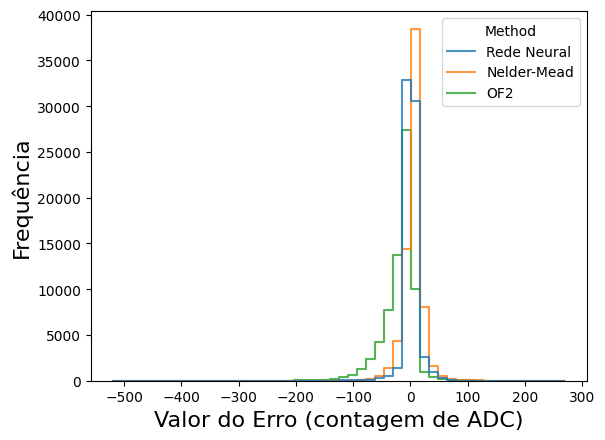

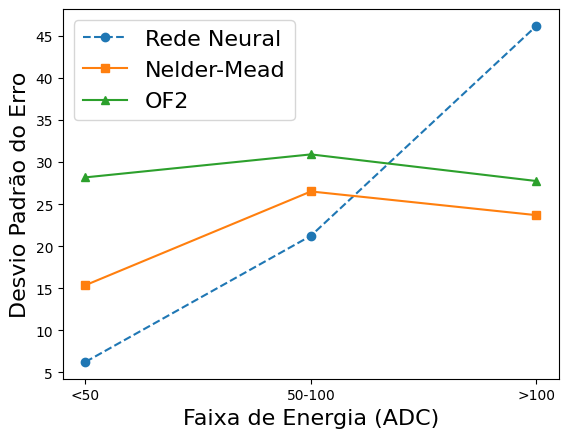

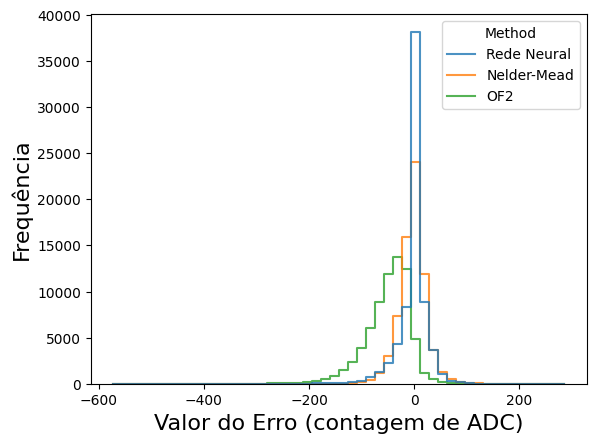

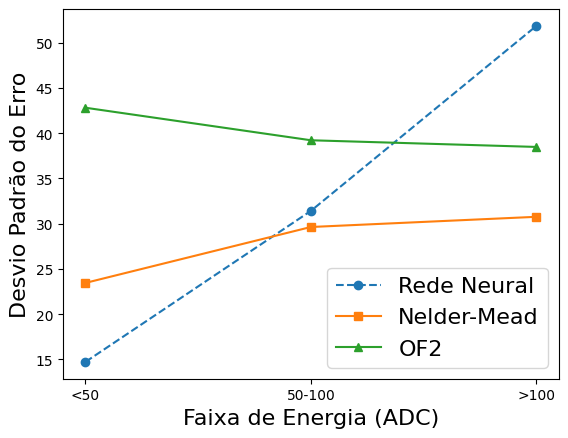

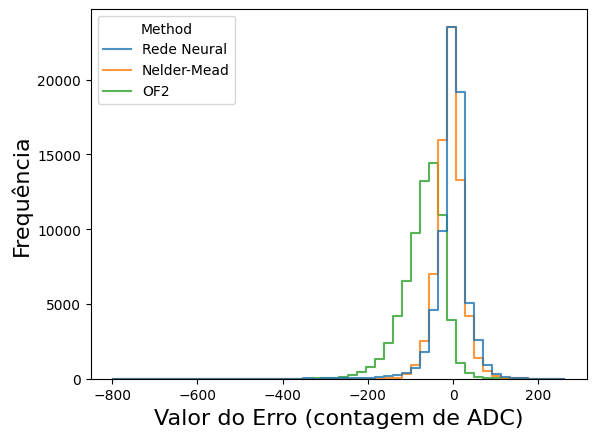

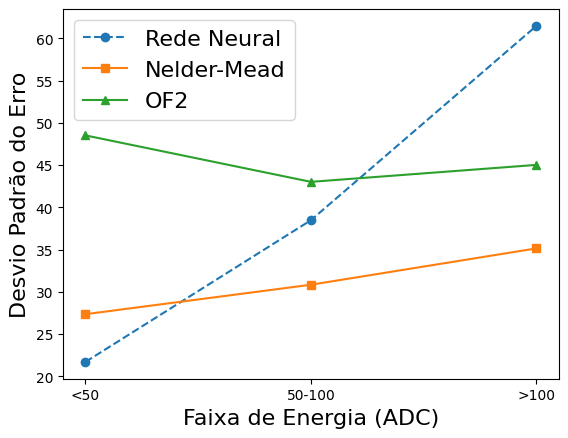

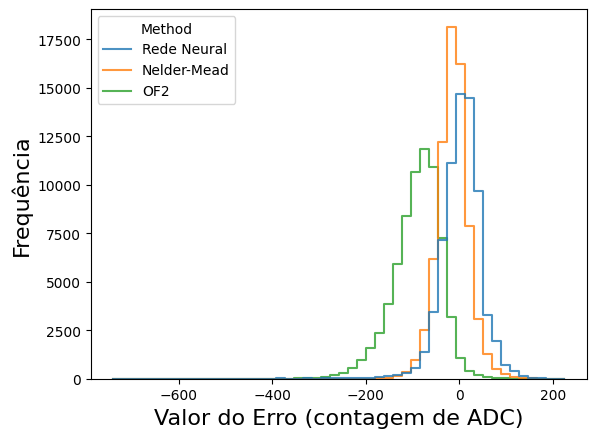

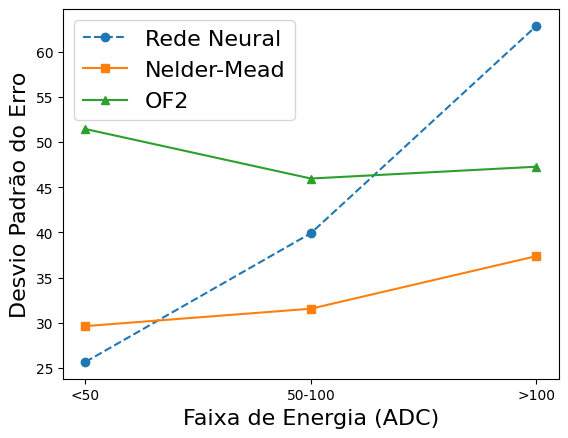

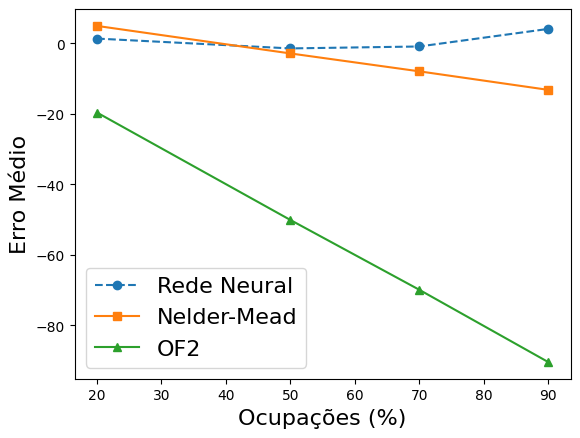

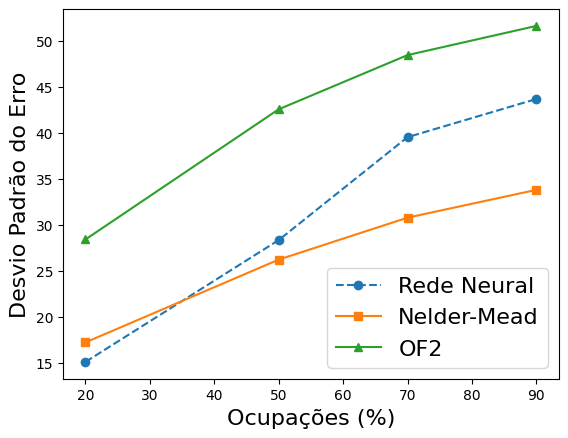

In [209]:
#Visualização dos resultados  


nm_residuals, nm_stats, nm_amplitudes, rn_residuals, rn_stats, rn_amplitudes, of2_residuals, of2_stats, of2_amplitudes = load_results()
nm_energias, rn_energias, of2_energias = load_energy(nm_amplitudes, rn_amplitudes, of2_amplitudes)

fsize = 16

palette = [
    "#1f77b4",  # Rede Neural
    "#ff7f0e",  # Nelder-Mead
    "#2ca02c",  # OF2
]

#Distribuição dos resíduos
for idx, occ in enumerate(occ_name):
    results = pd.concat([
            pd.DataFrame({"Residual Value": rn_residuals[occ], "Method": f"Rede Neural"}),
            pd.DataFrame({"Residual Value": nm_residuals[occ], "Method": f"Nelder-Mead"}),
            pd.DataFrame({"Residual Value": of2_residuals[occ], "Method": f"OF2"}),
        ])
    sns.histplot(data=results, hue="Method", legend=True, x="Residual Value", bins=50, fill=False, element="step", palette=palette, alpha=0.8)
    
    energia = ['<50', '50-100', '>100']

    plt.ylabel("Frequência", fontsize=fsize)
    plt.xlabel("Valor do Erro (contagem de ADC)", fontsize=fsize)
    plt.show()
    
    plt.plot(energia, rn_energias[occ], marker='o', color=palette[0], label='Rede Neural', linestyle='--')
    plt.plot(energia, nm_energias[occ], marker='s', color=palette[1], label='Nelder-Mead')
    plt.plot(energia, of2_energias[occ], marker='^', color=palette[2], label='OF2')
    plt.xlabel('Faixa de Energia (ADC)', fontsize=fsize)
    plt.ylabel('Desvio Padrão do Erro', fontsize=fsize)
    plt.legend(fontsize=fsize)
    plt.show()
occ = [20, 50, 70, 90]

#Graficos de Média e Desvio Padrão
plt.plot(occ, rn_stats['mean'], marker='o', color=palette[0], label='Rede Neural', linestyle='--')
plt.plot(occ, nm_stats['mean'], marker='s', color=palette[1], label='Nelder-Mead')
plt.plot(occ, of2_stats['mean'], marker='^', color=palette[2], label='OF2')
plt.xlabel('Ocupações (%)', fontsize=fsize)
plt.ylabel('Erro Médio', fontsize=fsize)
plt.legend(fontsize=fsize)
plt.show()

plt.plot(occ, rn_stats['std'], marker='o', color=palette[0], label='Rede Neural', linestyle='--')
plt.plot(occ, nm_stats['std'], marker='s', color=palette[1], label='Nelder-Mead')
plt.plot(occ, of2_stats['std'], marker='^', color=palette[2], label='OF2')
plt.xlabel('Ocupações (%)', fontsize=fsize)
plt.ylabel('Desvio Padrão do Erro', fontsize=fsize)
plt.legend(fontsize=fsize)
plt.show()